In [15]:
import numpy as np
from astropy.io import ascii
import matplotlib.pyplot as plt
def grmonty(file):
    """
    Reads SEDs in the format provided by grmonty. Ported from 
    the original SM script `plspec.m` provided by J. Dolence.
    
    Returns:
        lognu: Logarithmic frequency values
        ll: Logarithmic luminosity values in shape (6, s['colx'].shape)
    """
    LSUN = 3.827e33
    CL = 2.99792458e10
    ME = 9.1093826e-28
    HPL =  6.6260693e-27
    # Read the file using ascii
    s = ascii.read(file, format='no_header')


    # Array conversions for luminosity values (log10)
    ll = np.zeros((6, len(s)))  # Pre-allocate the array with shape (6, s['colx'].shape)
    ll[0] = np.array(s['col2'] * LSUN)
    ll[1] = np.array(s['col8'] * LSUN)
    ll[2] = np.array(s['col14']* LSUN)
    ll[3] = np.array(s['col20']* LSUN)
    ll[4] = np.array(s['col26']* LSUN)
    ll[5] = np.array(s['col32']* LSUN)
    
    tauabs = np.zeros((6, len(s)))  # Pre-allocate the array with shape (6, s['colx'].shape)
    tauabs[0] = np.array(s['col3'])    
    tauabs[1] = np.array(s['col9'])
    tauabs[2] = np.array(s['col15'])
    tauabs[3] = np.array(s['col21'])
    tauabs[4] = np.array(s['col27'])
    tauabs[5] = np.array(s['col33'])


    # Compute log frequency (log(nu)) values
    nu = np.array(10**s['col1'] * (ME * CL**2/HPL))
    #print(nu)
    # Return log(nu) and ll array
    return nu, ll, tauabs

#identify what folder i am in
#nu, nuLnu, tauabs = grmonty('/home/pedro/gpumontys/gpumonty_last/gpumonty/output/SPHERE_1e6.spec')
#nu_gr, nuLnu_gr = grmonty('/home/pedro/gpumontys/gpumonty_sphere/gpumonty/output/SPHERE.spec')
domega_array = np.array([4.281887e-01, 1.255386e+00, 1.997030e+00, 2.602581e+00, 3.030769e+00, 3.252416e+00])

In [16]:
nu, nuLnu, tauabs = grmonty('../output/sane_ben.spec')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


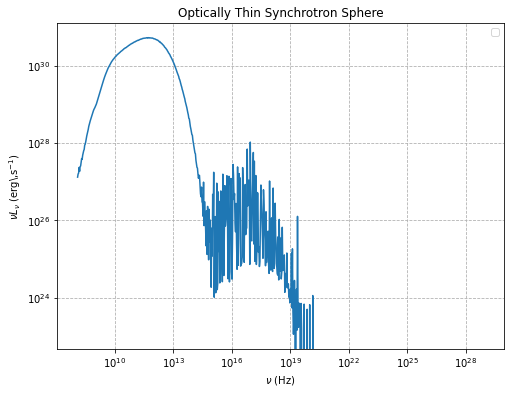

In [17]:

plt.figure(figsize=(8, 6))
nuLnu_avg = (nuLnu * domega_array[:, None] / (4 * np.pi)).sum(0)

plt.plot(nu, nuLnu_avg, linestyle='-')

plt.xlabel(r"$\nu$ (Hz)")
plt.ylabel(r"$\nu L_\nu$ (erg\,s$^{-1}$)")
plt.title("Optically Thin Synchrotron Sphere")
plt.xscale("log")
plt.yscale("log")
plt.grid(True, which="both", ls="--")
plt.legend()

plt.show()